# 3. Refund Behavior Analysis

What drives refunds? We examine refund rate against rating, delay, category, value and time-of-week.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

# Anchor to the repo root regardless of where the kernel starts.
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print("Repo root:", ROOT)


Repo root: V:\E-commerce Order Fulfillment Operations Analysis


In [2]:
df = pd.read_csv(ROOT / "data" / "processed" / "orders_clean.csv", parse_dates=["Order Date & Time"])
df["is_delayed"] = df["is_delayed"].astype(bool)
print("Rows:", len(df), "| Cols:", df.shape[1])
df.head()

Rows: 100000 | Cols: 16


,Order ID,Customer ID,Platform,Order Date & Time,Promised Delivery (Minutes),Actual Delivery (Minutes),Product Category,Order Value (INR),Items Count,Customer Feedback,Service Rating,Delivery Delay,Refund Requested,is_delayed,order_weekday,order_hour
0,ORD000001,CUST0002,Swiggy Instamart,2024-11-01 00:00:51,35,50,Personal Care,1490,3,"Horrible experience, never ordering again.",1,Yes,Yes,True,4,0
1,ORD000002,CUST0007,Blinkit,2024-11-01 00:05:10,29,24,Personal Care,966,2,Packaging could be better.,3,No,No,False,4,0
2,ORD000003,CUST0002,Swiggy Instamart,2024-11-01 00:08:29,23,16,Grocery,340,5,Product quality was average.,4,No,No,False,4,0
3,ORD000004,CUST0001,Swiggy Instamart,2024-11-01 00:15:19,31,44,Snacks,169,12,Items missing from order.,3,Yes,No,True,4,0
4,ORD000005,CUST0001,Swiggy Instamart,2024-11-01 00:17:23,32,27,Personal Care,172,2,Cold items arrived melted.,2,No,No,False,4,0


## Overall refund rate

Overall refund rate: 18.75% (18,751 of 100,000 orders)


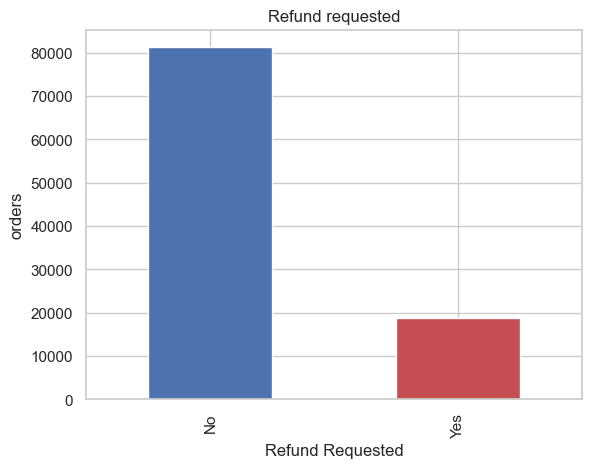

In [3]:
ref = df['Refund Requested'].eq('Yes')
print(f'Overall refund rate: {100 * ref.mean():.2f}% ({int(ref.sum()):,} of {len(df):,} orders)')
df['Refund Requested'].value_counts().plot(kind='bar', color=['#4C72B0', '#C44E52'], title='Refund requested')
plt.ylabel('orders'); plt.show()

## Refund rate by service rating (strongest driver)

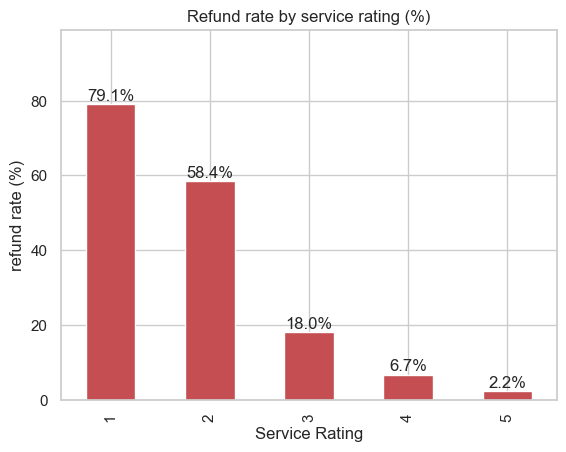

In [4]:
r = df.groupby('Service Rating')['Refund Requested'].apply(lambda s: 100 * s.eq('Yes').mean())
ax = r.plot(kind='bar', color='#C44E52', title='Refund rate by service rating (%)')
plt.ylabel('refund rate (%)')
for i, v in enumerate(r.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center')
plt.ylim(0, r.max() * 1.25); plt.show()

## Refund rate by delivery status

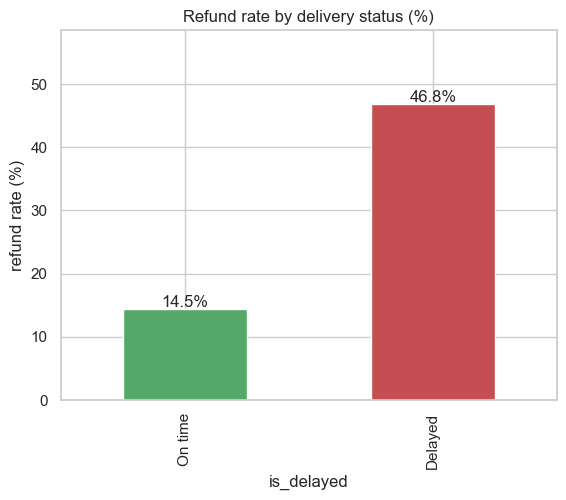

In [5]:
d = df.groupby('is_delayed')['Refund Requested'].apply(lambda s: 100 * s.eq('Yes').mean())
d.rename(index={False: 'On time', True: 'Delayed'}).plot(kind='bar', color=['#55A868', '#C44E52'], title='Refund rate by delivery status (%)')
plt.ylabel('refund rate (%)')
for i, v in enumerate(d.values):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center')
plt.ylim(0, d.max() * 1.25); plt.show()

## Refund rate by category and order-value bucket

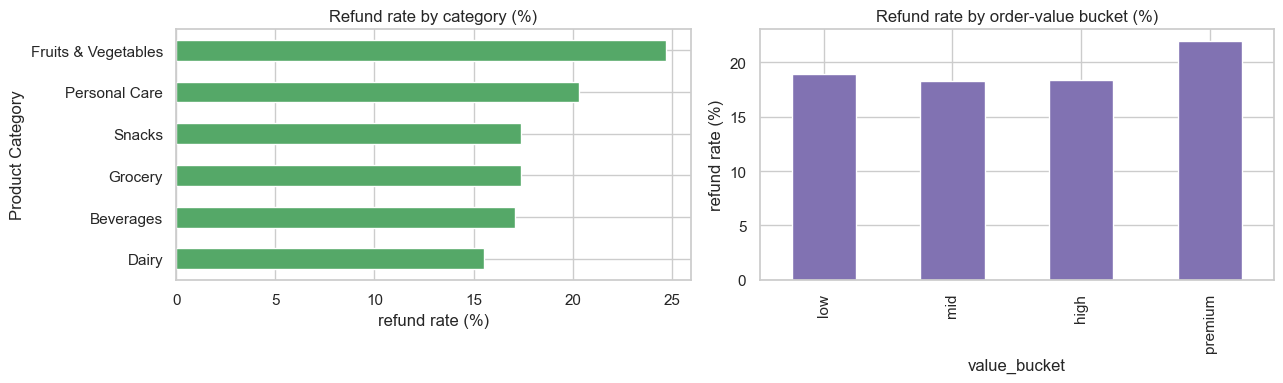

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cc = df.groupby('Product Category')['Refund Requested'].apply(lambda s: 100 * s.eq('Yes').mean()).sort_values()
cc.plot(kind='barh', ax=axes[0], color='#55A868', title='Refund rate by category (%)')
axes[0].set_xlabel('refund rate (%)')
feat = pd.read_csv(ROOT / 'data' / 'processed' / 'features.csv')
vb = feat.groupby('value_bucket', observed=True)['refund_requested'].mean() * 100
vb.reindex(['low', 'mid', 'high', 'premium']).plot(kind='bar', ax=axes[1], color='#8172B2', title='Refund rate by order-value bucket (%)')
axes[1].set_ylabel('refund rate (%)')
plt.tight_layout(); plt.show()

## Refund by day of week / hour (heatmap)

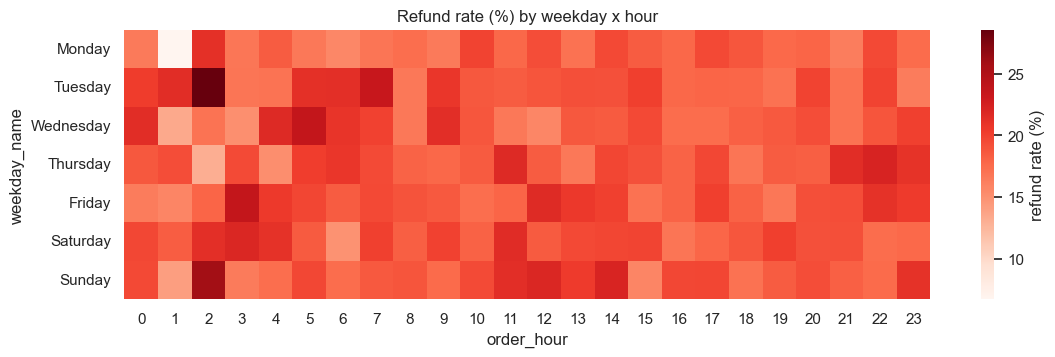

In [7]:
df['weekday_name'] = df['Order Date & Time'].dt.day_name()
wd_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
piv = df.pivot_table(index='weekday_name', columns='order_hour', values='Refund Requested', aggfunc=lambda s: 100 * s.eq('Yes').mean())
piv = piv.reindex(wd_order)
plt.figure(figsize=(13, 3.5))
sns.heatmap(piv, cmap='Reds', cbar_kws={'label': 'refund rate (%)'})
plt.title('Refund rate (%) by weekday x hour')
plt.show()

## Key takeaways
- **Service rating dominates**: refund rate ranges from **79.1% at rating 1** to **2.3% at rating 5** - strong but *not* deterministic (the original data had exactly 100%/0%).
- **Delivery delay matters**: delayed orders refund at **46.8%** vs **14.5%** on-time - a ~3.2x lift, so delay is a real secondary driver.
- **Category**: Fruits & Vegetables and Grocery refund at higher rates, consistent with their fragility.
- **Value interaction**: higher-value orders refund more often, giving the model an interaction signal (`delay_and_high_value`).
- Refund pressure is fairly uniform across the week - the rating/delay/value effects dominate timing.
- **This notebook reproduces `SQL/refund_analysis.sql`.**